# HR-аналитика: удовлетворённость и риск увольнения

## Описание проекта

Компания «Работа с заботой» хочет предотвращать внезапные увольнения,
особенно ключевых специалистов. Проект решает две связанные задачи:

1. **Регрессия:** предсказать уровень удовлетворённости сотрудника работой (0–1) — это
   снижает зависимость от ручных опросников.
2. **Классификация:** предсказать, уволится ли сотрудник — а в качестве одного из
   входных признаков используется удовлетворённость, предсказанная моделью из
   задачи 1 (в реальных данных `job_satisfaction_rate` для будущих сотрудников
   попросту неизвестен, поэтому его нужно оценивать отдельной моделью).

**Метрики:** SMAPE для задачи 1, ROC-AUC для задачи 2.

**План работы:**
1. Загрузить данные обеих задач, изучить структуру
2. Предобработка: опечатки, пропуски, объединение тестовых признаков и таргетов
3. Задача 1: EDA, пайплайн с кодированием и заполнением пропусков, сравнение моделей, SMAPE на тесте
4. Проверить, что обучающие выборки задач 1 и 2 не пересекаются по `id` — только тогда предсказанную удовлетворённость можно использовать как признак в задаче 2, не как утечку
5. Задача 2: EDA, добавление предсказанной удовлетворённости как признака, сравнение моделей, ROC-AUC на тесте, важность признаков

## Описание данных

- `id` — уникальный идентификатор сотрудника
- `dept` — отдел
- `level` — уровень должности (`junior`/`middle`/`senior`)
- `workload` — загруженность (`low`/`medium`/`high`)
- `employment_years` — стаж в компании, лет
- `last_year_promo` — было ли повышение за последний год
- `last_year_violations` — было ли нарушение трудового договора за последний год
- `supervisor_evaluation` — оценка руководителя, 1–5
- `salary` — ежемесячная зарплата
- `job_satisfaction_rate` — целевой признак задачи 1 (только в данных задачи 1)
- `quit` — целевой признак задачи 2 (только в данных задачи 2)

Данные разбиты на 5 файлов: обучающая и тестовая выборки для каждой задачи,
причём входные признаки тестовой выборки — один и тот же файл для обеих задач
(`test_features.csv`), то есть одни и те же 2000 сотрудников. Данные
предоставлены курсом и не публикуются.

## Подготовка к проекту

### Импорт библиотек и константы

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from scipy.stats import ttest_ind, levene

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

pd.set_option('display.float_format', '{:,.2f}'.format)

### Вспомогательные функции

In [2]:
def print_unique_categorical_values(df):
    categorical_columns = df.select_dtypes(include='object').columns
    if len(categorical_columns) == 0:
        print("В датафрейме нет категориальных столбцов.")
        return
    for column in categorical_columns:
        unique_values = df[column].unique()
        print(f"Уникальные значения в колонке '{column}':")
        print(unique_values)
        print("-" * 50)

In [3]:
def f_hist_box(train, test, bins, range, title, xlabel, ylabel):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, figsize=(10, 5), gridspec_kw={"height_ratios": (.15, .85)})
    sns.boxplot(data=[train, test], orient="h", ax=ax_box)
    plt.hist([train, test], bins=bins, range=range, label=['train', 'test'])
    plt.legend(loc='upper right')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

In [4]:
def f_countplot(train, test, suptitle, xlabel, ylabel):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))
    fig.tight_layout(h_pad=3)
    fig.suptitle(suptitle, x=0.5, y=1.07, fontsize=16)
    sns.countplot(x=train, ax=ax1)
    sns.countplot(x=test, ax=ax2)
    ax1.set_title('График подсчета для тренировочной выборки')
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel)
    ax2.set_title('График подсчета для тестовой выборки')
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel(ylabel)

In [5]:
def f_pie_x2(train, test, col, suptitle):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))
    fig.suptitle(suptitle, x=0.5, y=0.75, fontsize=12)
    train.pivot_table(index=col, values='id', aggfunc='count').plot.pie(
        y='id', autopct='%1.0f%%', figsize=(10, 10), ax=ax1, label='Доля')
    test.pivot_table(index=col, values='id', aggfunc='count').plot.pie(
        y='id', autopct='%1.0f%%', figsize=(10, 10), ax=ax2, label='Доля')
    ax1.set_title('train')
    ax2.set_title('test')
    plt.tight_layout()
    plt.show()

Функцию для сравнения train/test по пробным значениям и очистке дубликатов пробелов и опечаток оставляем отдельно — заполнение пропусков делает `SimpleImputer` внутри пайплайна, здесь только нормализация обозначений.

In [6]:
def clean_categorical(df, level_col='level'):
    df = df.copy()
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].replace(' ', np.nan)
    if level_col in df.columns:
        df[level_col] = df[level_col].replace('sinior', 'senior')
    return df

# Задача 1: прогноз удовлетворённости работой

## Загрузка данных

In [7]:
train_sat = pd.read_csv('data/train_job_satisfaction_rate.csv')
test_features = pd.read_csv('data/test_features.csv')
test_target_sat = pd.read_csv('data/test_target_job_satisfaction_rate.csv')

print(train_sat.shape, test_features.shape, test_target_sat.shape)
train_sat.info()

(4000, 10) (2000, 9) (2000, 2)
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   str    
 2   level                  3996 non-null   str    
 3   workload               4000 non-null   str    
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   str    
 6   last_year_violations   4000 non-null   str    
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), str(5)
memory usage: 312.6 KB


## Предобработка

В `test_features` часть пропусков в `dept`/`workload` записана не как `NaN`,
а как строка из одного пробела — `SimpleImputer` такие пропуски не увидит,
поэтому приводим их к `NaN`. Заодно исправляем опечатку `sinior` → `senior` в `level`.

In [8]:
train_sat = clean_categorical(train_sat)
test_features = clean_categorical(test_features)

print("Дубликатов в train:", train_sat.duplicated().sum())
print_unique_categorical_values(train_sat)

Дубликатов в train: 0
Уникальные значения в колонке 'dept':
<StringArray>
['sales', 'hr', 'technology', 'purchasing', 'marketing', nan]
Length: 6, dtype: str
--------------------------------------------------
Уникальные значения в колонке 'level':
<StringArray>
['junior', 'middle', 'senior', nan]
Length: 4, dtype: str
--------------------------------------------------
Уникальные значения в колонке 'workload':
<StringArray>
['medium', 'high', 'low']
Length: 3, dtype: str
--------------------------------------------------
Уникальные значения в колонке 'last_year_promo':
<StringArray>
['no', 'yes']
Length: 2, dtype: str
--------------------------------------------------
Уникальные значения в колонке 'last_year_violations':
<StringArray>
['no', 'yes']
Length: 2, dtype: str
--------------------------------------------------


C:\Users\krbsv\AppData\Local\Temp\ipykernel_8800\3034590545.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:
C:\Users\krbsv\AppData\Local\Temp\ipykernel_8800\3034590545.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mi

Объединим признаки теста с целевым значением и проверим, что объединение не потеряло строк и что множества `id` train/test не пересекаются.

In [9]:
test_sat = test_features.merge(test_target_sat, on='id')
assert len(test_sat) == len(test_features) == len(test_target_sat)
assert set(train_sat.columns) == set(test_sat.columns)

overlap = set(train_sat['id']) & set(test_sat['id'])
print(f"Пересечение id train/test задачи 1: {len(overlap)}")

Пересечение id train/test задачи 1: 0


### Вывод по предобработке данных
+ Во всех столбцах верно указаны типы данных.
+ В данных нет дубликатов.
+ Пропущенные значения приведены к общему виду `np.nan`. Дальнейшее заполнение пропусков будет проведено в пайплайне при обучении модели.
+ Ошибки в текстовых обозначениях данных исправлены.
+ id train и test не пересекаются.

## Исследовательский анализ данных

### Количественные данные

In [10]:
train_sat.describe()

,id,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,"4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,"544,957.62",3.72,3.48,"33,926.70",0.53
std,"257,883.10",2.54,1.01,"14,900.70",0.23
min,"100,954.00",1.00,1.00,"12,000.00",0.03
25%,"322,836.75",2.00,3.00,"22,800.00",0.36
50%,"534,082.50",3.00,4.00,"30,000.00",0.56
75%,"771,446.00",6.00,4.00,"43,200.00",0.71
max,"999,521.00",10.00,5.00,"98,400.00",1.00


In [11]:
test_sat.describe()

,id,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,"2,000.00","2,000.00","2,000.00","2,000.00","2,000.00"
mean,"552,765.21",3.67,3.53,"34,066.80",0.55
std,"253,851.33",2.54,1.00,"15,398.44",0.22
min,"100,298.00",1.00,1.00,"12,000.00",0.03
25%,"339,052.00",1.00,3.00,"22,800.00",0.38
50%,"550,793.00",3.00,4.00,"30,000.00",0.58
75%,"765,763.75",6.00,4.00,"43,200.00",0.72
max,"999,029.00",10.00,5.00,"96,000.00",1.00


### Количественные данные. Графики подсчета.

Исследование `employment_years`.

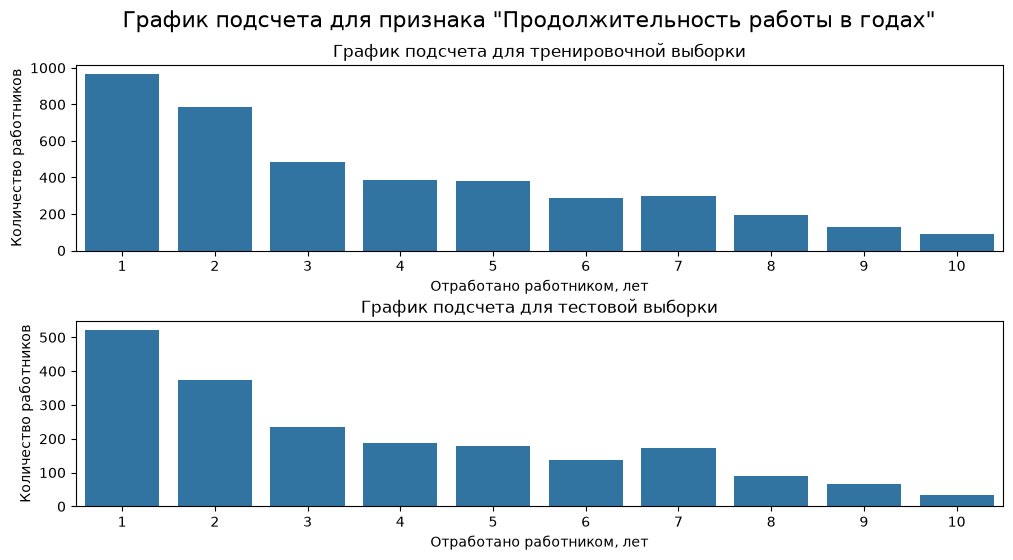

In [12]:
f_countplot(
    train=train_sat['employment_years'],
    test=test_sat['employment_years'],
    suptitle='График подсчета для признака "Продолжительность работы в годах"',
    xlabel='Отработано работником, лет',
    ylabel='Количество работников'
)

Исследование `supervisor_evaluation`.

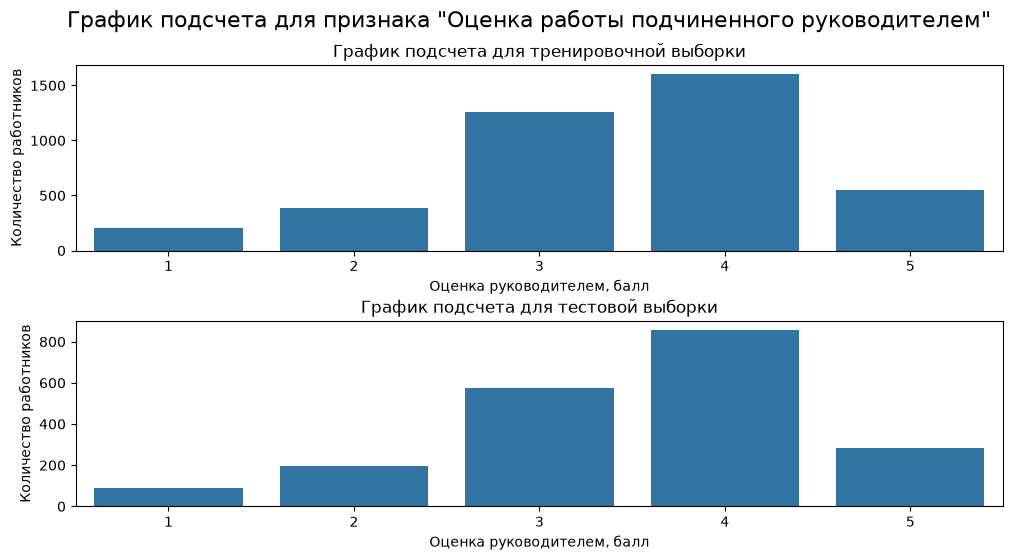

In [13]:
f_countplot(
    train=train_sat['supervisor_evaluation'],
    test=test_sat['supervisor_evaluation'],
    suptitle='График подсчета для признака "Оценка работы подчиненного руководителем"',
    xlabel='Оценка руководителем, балл',
    ylabel='Количество работников'
)

### Количественные данные. Гистограммы и ящики с усами.

Исследование `salary`.

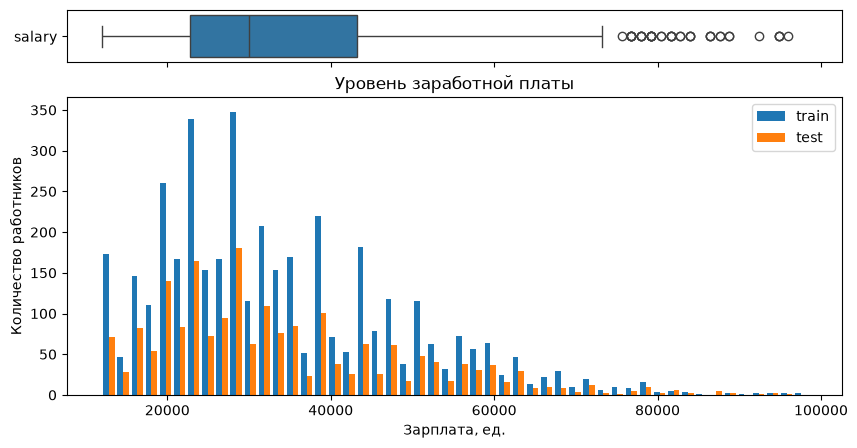

In [14]:
f_hist_box(
    train=train_sat['salary'],
    test=test_sat['salary'],
    bins=50,
    range=(train_sat['salary'].min(), train_sat['salary'].max()),
    title='Уровень заработной платы',
    xlabel='Зарплата, ед.',
    ylabel='Количество работников'
)

Исследование `job_satisfaction_rate`.

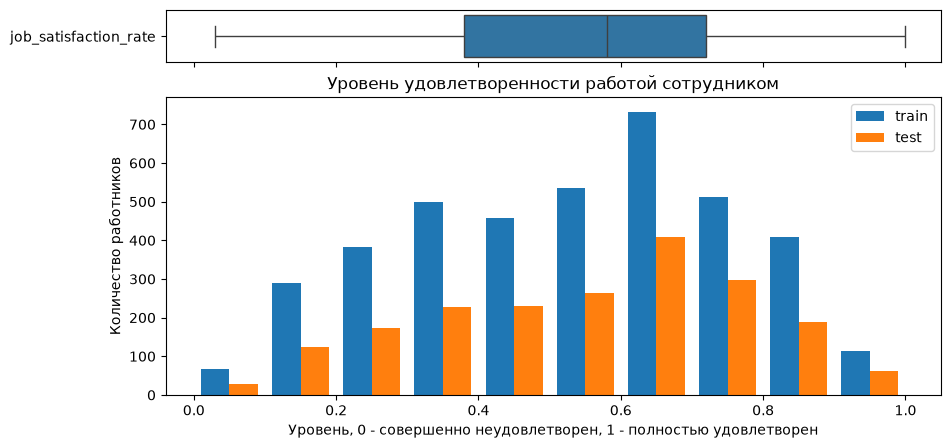

In [15]:
f_hist_box(
    train=train_sat['job_satisfaction_rate'],
    test=test_sat['job_satisfaction_rate'],
    bins=10,
    range=(0, 1),
    title='Уровень удовлетворенности работой сотрудником',
    xlabel='Уровень, 0 - совершенно неудовлетворен, 1 - полностью удовлетворен',
    ylabel='Количество работников'
)

### Качественные данные

In [16]:
train_sat.describe(include='object')

C:\Users\krbsv\AppData\Local\Temp\ipykernel_8800\3577951303.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train_sat.describe(include='object')


,dept,level,workload,last_year_promo,last_year_violations
count,3994,3996,4000,4000,4000
unique,5,3,3,2,2
top,sales,junior,medium,no,no
freq,1512,1894,2066,3880,3441


In [17]:
test_sat.describe(include='object')

C:\Users\krbsv\AppData\Local\Temp\ipykernel_8800\471808655.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  test_sat.describe(include='object')


,dept,level,workload,last_year_promo,last_year_violations
count,1997,1999,1999,2000,2000
unique,5,3,3,2,2
top,sales,junior,medium,no,no
freq,763,974,1043,1937,1738


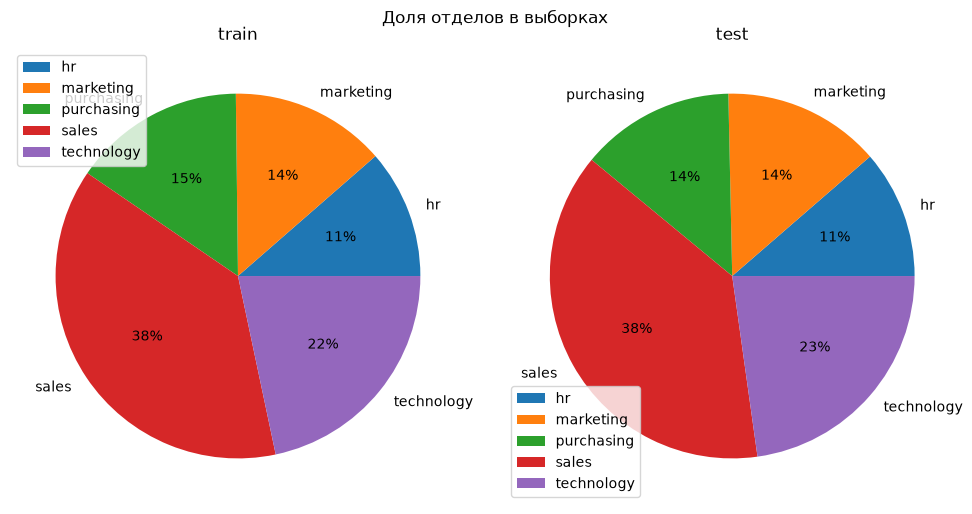

In [18]:
f_pie_x2(train=train_sat, test=test_sat, col='dept', suptitle='Доля отделов в выборках')

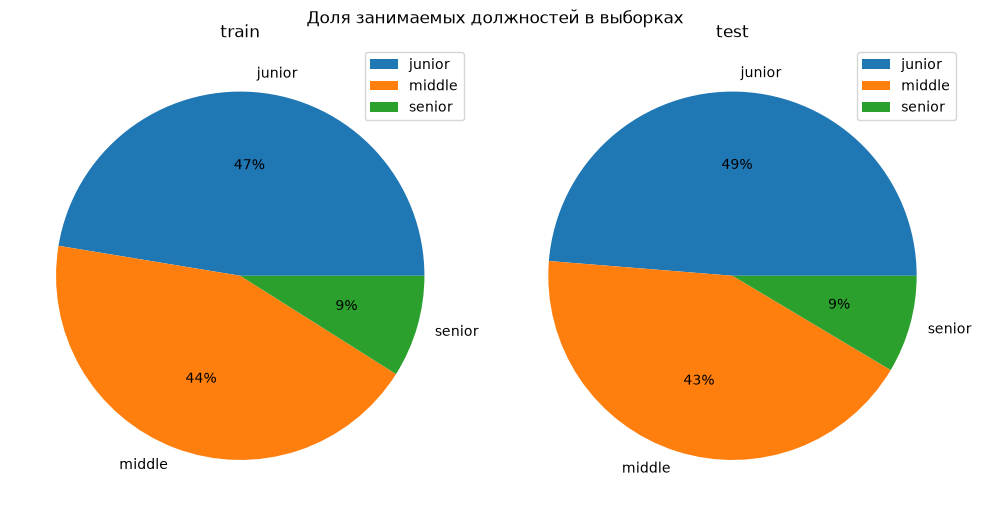

In [19]:
f_pie_x2(train=train_sat, test=test_sat, col='level', suptitle='Доля занимаемых должностей в выборках')

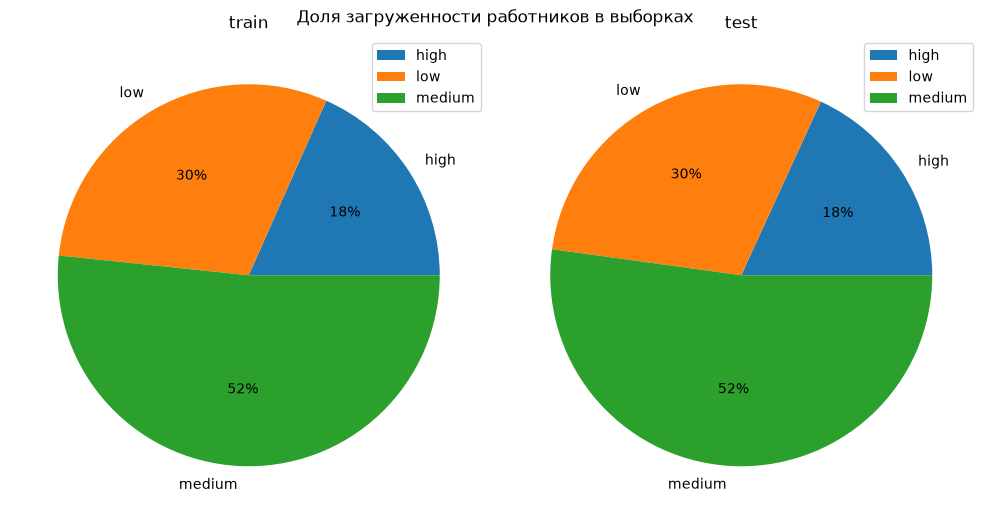

In [20]:
f_pie_x2(train=train_sat, test=test_sat, col='workload', suptitle='Доля загруженности работников в выборках')

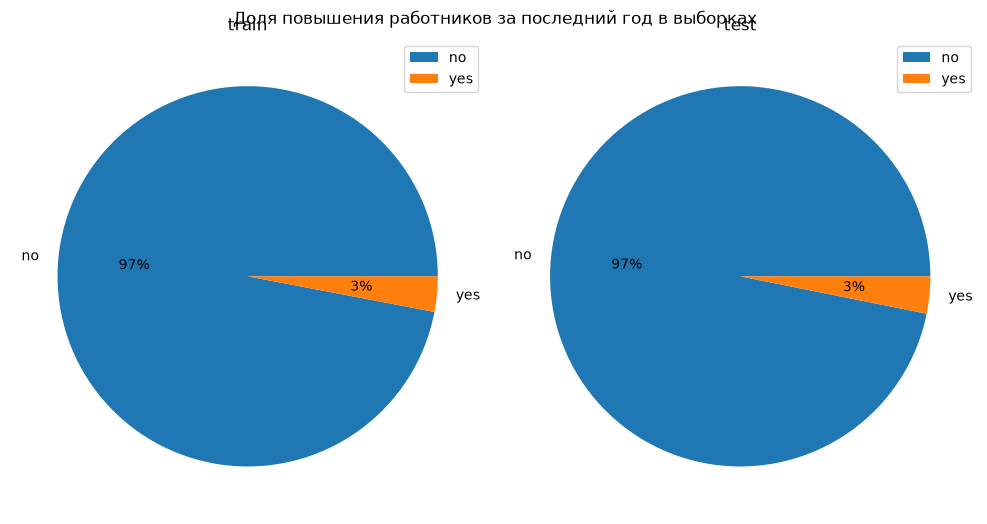

In [21]:
f_pie_x2(train=train_sat, test=test_sat, col='last_year_promo', suptitle='Доля повышения работников за последний год в выборках')

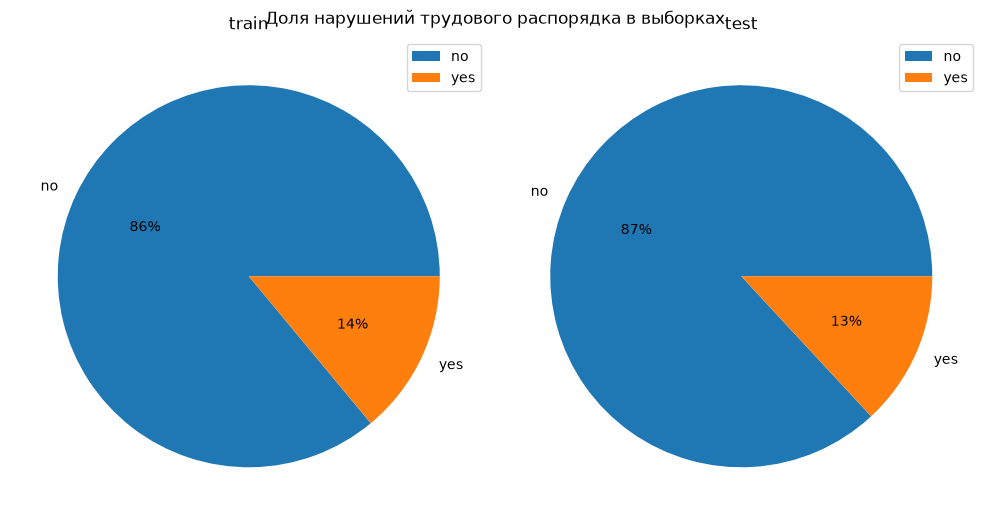

In [22]:
f_pie_x2(train=train_sat, test=test_sat, col='last_year_violations', suptitle='Доля нарушений трудового распорядка в выборках')

### Вывод по анализу данных

+ `employment_years` — количество работников убывает с ростом стажа, распределения похожи в train и test.
+ `supervisor_evaluation` — большая часть работников получает оценку 4, графики почти совпадают.
+ `salary` — пик около 30000, дальше распределение снижается, train и test согласованы.
+ `job_satisfaction_rate` — распределения train и test совпадают.
+ `dept`, `level`, `workload`, `last_year_promo`, `last_year_violations` — доли категорий в train и test близки друг к другу, тестовая выборка репрезентативна.

### Корреляционный анализ

Сделаем столбец `id` индексным перед расчётом корреляций.

In [23]:
train_sat_idx = train_sat.set_index('id').sort_index()
test_sat_idx = test_sat.set_index('id').sort_index()

Проведём исследование корреляций признаков для исключения мультиколлинеарности. `interval_cols` — непрерывные числовые признаки.

In [24]:
interval_cols = ['salary', 'job_satisfaction_rate']

Построим матрицы корреляций для тренировочной и тестовой выборок.

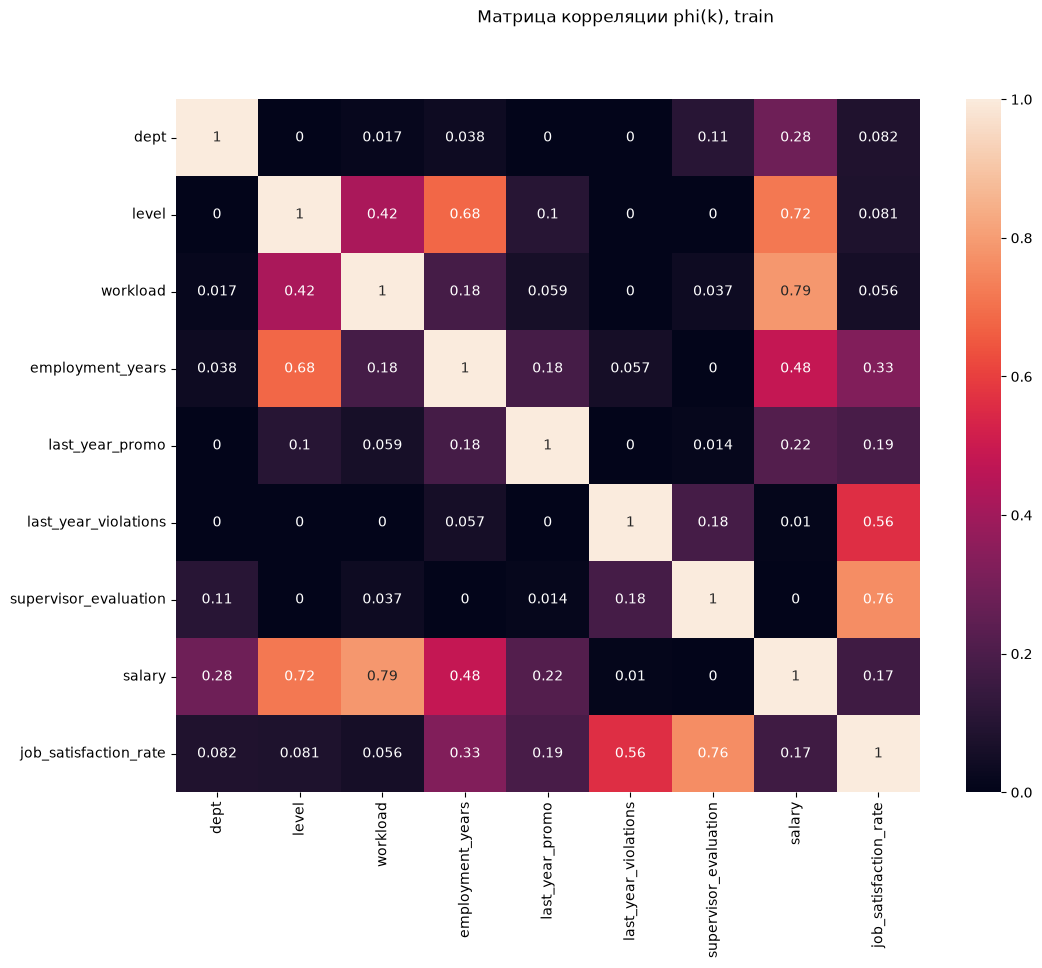

In [25]:
fig, ax = plt.subplots(figsize=(12, 9))
plt.suptitle('Матрица корреляции phi(k), train')
sns.heatmap(train_sat_idx.phik_matrix(interval_cols=interval_cols), annot=True)
plt.show()

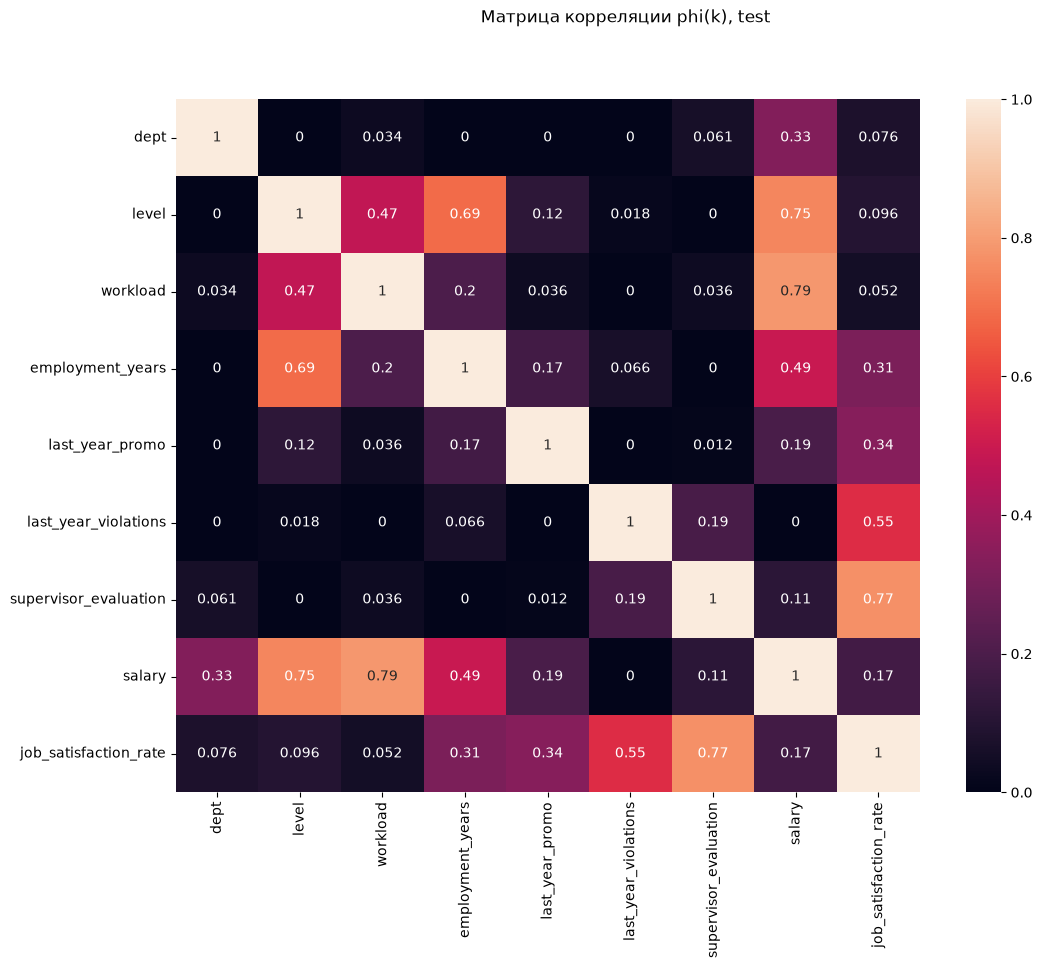

In [26]:
fig, ax = plt.subplots(figsize=(12, 9))
plt.suptitle('Матрица корреляции phi(k), test')
sns.heatmap(test_sat_idx.phik_matrix(interval_cols=interval_cols), annot=True)
plt.show()

### Вывод по корреляционному анализу
+ Данные `id` переведены в индекс.
+ Между входными признаками нет связи выше 0.9, мультиколлинеарность не проблема.
+ На train и test значения корреляции немного различаются, но общая картина совпадает.
+ `dept`, `last_year_promo`, `last_year_violations` — кодируем `OneHotEncoder` (номинальные категории).
+ `level`, `workload` — кодируем `OrdinalEncoder` с явным порядком (они по сути ранговые).
+ `employment_years`, `supervisor_evaluation`, `salary` — масштабируем.

## Пайплайн и метрика SMAPE

In [27]:
num_cols_1 = ['employment_years', 'supervisor_evaluation', 'salary']
ohe_cols = ['dept', 'last_year_promo', 'last_year_violations']
ord_cols = ['level', 'workload']

preprocessor_1 = ColumnTransformer([
    ('ohe', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
    ]), ohe_cols),
    ('ord', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(categories=[
            ['junior', 'middle', 'senior'],
            ['low', 'medium', 'high'],
        ], handle_unknown='use_encoded_value', unknown_value=np.nan)),
    ]), ord_cols),
    ('num', RobustScaler(), num_cols_1),
])

def smape(y_true, y_pred):
    return 100 / len(y_true) * np.sum(
        np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2)
    )

smape_scorer = make_scorer(smape, greater_is_better=False)

## Обучение моделей

In [28]:
X_train_1 = train_sat_idx.drop(columns='job_satisfaction_rate')
y_train_1 = train_sat_idx['job_satisfaction_rate']
X_test_1 = test_sat_idx.drop(columns='job_satisfaction_rate')
y_test_1 = test_sat_idx['job_satisfaction_rate']

models_1 = {
    'LinearRegression': (Pipeline([('preprocessor', preprocessor_1), ('model', LinearRegression())]), {}),
    'DecisionTreeRegressor': (
        Pipeline([('preprocessor', preprocessor_1), ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))]),
        {'model__max_depth': [None, 3, 5, 7, 10], 'model__max_features': range(2, 12)}
    ),
    'HistGradientBoostingRegressor': (
        Pipeline([('preprocessor', preprocessor_1), ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE))]),
        {'model__max_depth': [None, 3, 5, 7], 'model__learning_rate': [0.03, 0.05, 0.1, 0.2], 'model__max_iter': [100, 200]}
    ),
}

results_1 = []
for name, (pipe, params) in models_1.items():
    if params:
        search = RandomizedSearchCV(pipe, params, n_iter=20, cv=5, scoring=smape_scorer, random_state=RANDOM_STATE, n_jobs=-1)
        search.fit(X_train_1, y_train_1)
        best_est, cv_smape = search.best_estimator_, -search.best_score_
    else:
        pipe.fit(X_train_1, y_train_1)
        from sklearn.model_selection import cross_val_score
        scores = cross_val_score(pipe, X_train_1, y_train_1, cv=5, scoring=smape_scorer, n_jobs=-1)
        best_est, cv_smape = pipe, -scores.mean()
    results_1.append({'model': name, 'cv_smape': cv_smape, 'estimator': best_est})
    print(f"{name:28s} CV SMAPE = {cv_smape:.3f}")

LinearRegression             CV SMAPE = 25.023


DecisionTreeRegressor        CV SMAPE = 15.485


HistGradientBoostingRegressor CV SMAPE = 11.382


## Выбор модели и проверка на тесте

In [29]:
results_1_df = pd.DataFrame(results_1).sort_values('cv_smape')
display(results_1_df[['model', 'cv_smape']])

best_1 = results_1_df.iloc[0]
best_model_1_name, best_model_1 = best_1['model'], best_1['estimator']

test_pred_1 = best_model_1.predict(X_test_1)
test_smape = smape(y_test_1, test_pred_1)
print(f"\nЛучшая модель: {best_model_1_name}")
print(f"SMAPE на тесте: {test_smape:.3f}")

dummy_1 = DummyRegressor(strategy='median').fit(X_train_1, y_train_1)
print(f"SMAPE DummyRegressor на тесте: {smape(y_test_1, dummy_1.predict(X_test_1)):.3f}")

,model,cv_smape
2,HistGradientBoostingRegressor,11.38
1,DecisionTreeRegressor,15.49
0,LinearRegression,25.02



Лучшая модель: HistGradientBoostingRegressor
SMAPE на тесте: 10.926
SMAPE DummyRegressor на тесте: 37.553


## Вывод по задаче 1

Лучшая модель значительно превосходит `DummyRegressor`: прогноз меняется от сотрудника
к сотруднику, а не сводится к одному числу. Линейная связь между признаками
и удовлетворённостью слабая (видна уже в матрице корреляций), поэтому деревья
и бустинг обходят линейную регрессию.

# Задача 2: прогноз увольнения

## Загрузка данных

`test_features` для задачи 2 — тот же файл, что и в задаче 1 (одни и те же 2000 сотрудников), уже очищен выше.

In [30]:
train_quit = pd.read_csv('data/train_quit.csv')
test_features_2 = test_features.copy()
test_target_quit = pd.read_csv('data/test_target_quit.csv')

train_quit = clean_categorical(train_quit)
print(train_quit.shape, test_features_2.shape, test_target_quit.shape)
print("Дубликатов в train_quit:", train_quit.duplicated().sum())

(4000, 10) (2000, 9) (2000, 2)
Дубликатов в train_quit: 0


C:\Users\krbsv\AppData\Local\Temp\ipykernel_8800\3034590545.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [31]:
test_quit = test_features_2.merge(test_target_quit, on='id')
assert len(test_quit) == len(test_features_2) == len(test_target_quit)

## Проверка независимости обучающих выборок задач 1 и 2

Удовлетворённость, предсказанная моделью задачи 1, добавляется как признак в
задачу 2. Это не утечка, только если модель задачи 1 не видела на обучении тех
сотрудников, для которых потом предсказывает удовлетворённость в задаче 2.

In [32]:
overlap_train = set(train_sat_idx.index) & set(train_quit['id'])
overlap_test = set(test_sat_idx.index) & set(train_quit['id'])
print(f"Пересечение id: train_sat & train_quit = {len(overlap_train)}")
print(f"Пересечение id: test (общий) & train_quit = {len(overlap_test)}")

assert len(overlap_train) == 0, "Обучающие выборки задач 1 и 2 пересекаются"
print("Пересечений нет: предсказанная удовлетворённость будет out-of-sample признаком.")

Пересечение id: train_sat & train_quit = 0
Пересечение id: test (общий) & train_quit = 0
Пересечений нет: предсказанная удовлетворённость будет out-of-sample признаком.


## Исследовательский анализ данных

### Количественные данные

Исследование числовых показателей.

In [33]:
train_quit.describe()

,id,employment_years,supervisor_evaluation,salary
count,"4,000.00","4,000.00","4,000.00","4,000.00"
mean,"552,099.28",3.70,3.47,"33,805.80"
std,"260,158.03",2.54,1.00,"15,152.42"
min,"100,222.00",1.00,1.00,"12,000.00"
25%,"327,785.75",2.00,3.00,"22,800.00"
50%,"546,673.00",3.00,4.00,"30,000.00"
75%,"781,497.75",6.00,4.00,"43,200.00"
max,"999,915.00",10.00,5.00,"96,000.00"


In [34]:
test_quit.describe()

,id,employment_years,supervisor_evaluation,salary
count,"2,000.00","2,000.00","2,000.00","2,000.00"
mean,"552,765.21",3.67,3.53,"34,066.80"
std,"253,851.33",2.54,1.00,"15,398.44"
min,"100,298.00",1.00,1.00,"12,000.00"
25%,"339,052.00",1.00,3.00,"22,800.00"
50%,"550,793.00",3.00,4.00,"30,000.00"
75%,"765,763.75",6.00,4.00,"43,200.00"
max,"999,029.00",10.00,5.00,"96,000.00"


Исследование `employment_years`.

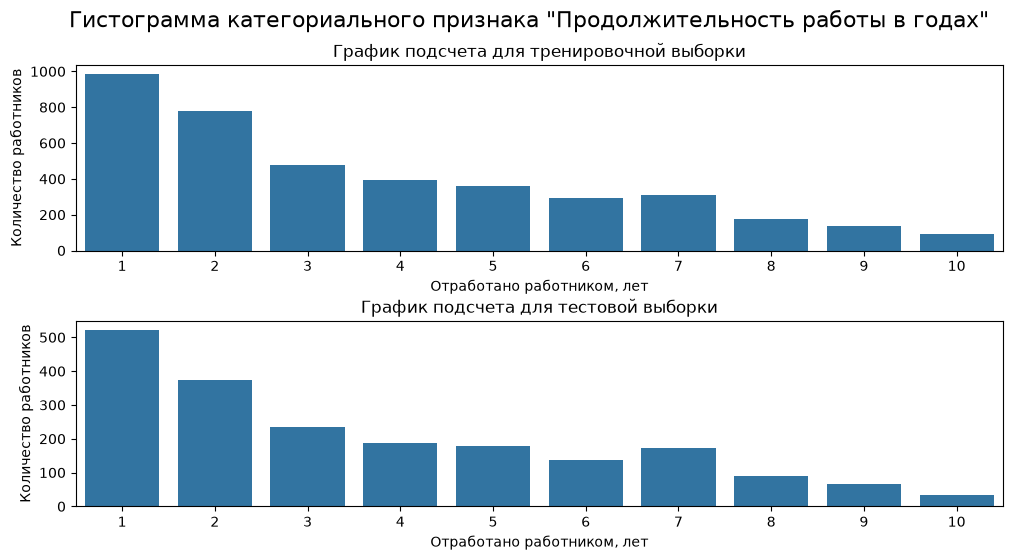

In [35]:
f_countplot(
    train=train_quit['employment_years'],
    test=test_quit['employment_years'],
    suptitle='Гистограмма категориального признака "Продолжительность работы в годах"',
    xlabel='Отработано работником, лет',
    ylabel='Количество работников'
)

Исследование `supervisor_evaluation`.

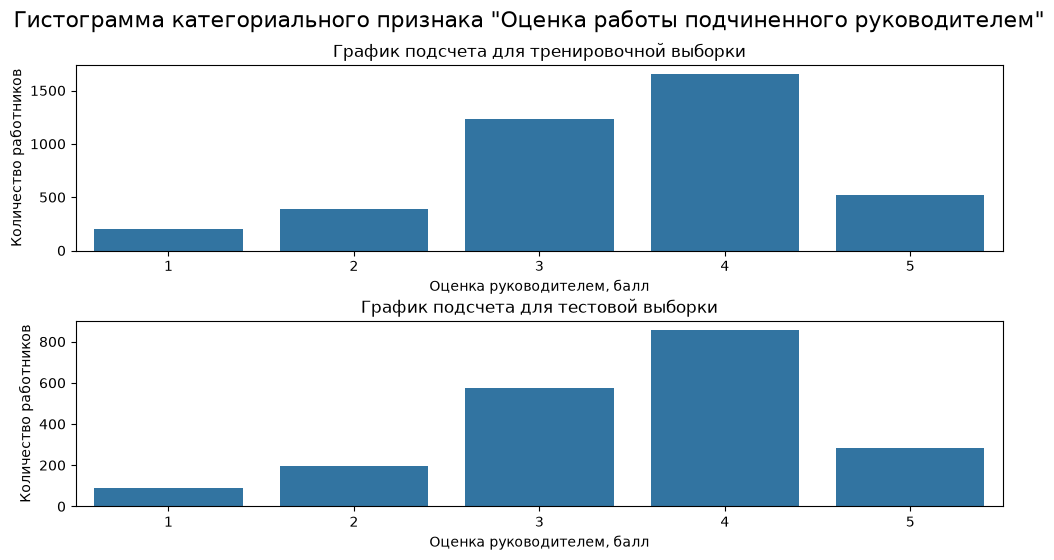

In [36]:
f_countplot(
    train=train_quit['supervisor_evaluation'],
    test=test_quit['supervisor_evaluation'],
    suptitle='Гистограмма категориального признака "Оценка работы подчиненного руководителем"',
    xlabel='Оценка руководителем, балл',
    ylabel='Количество работников'
)

Исследование `salary`.

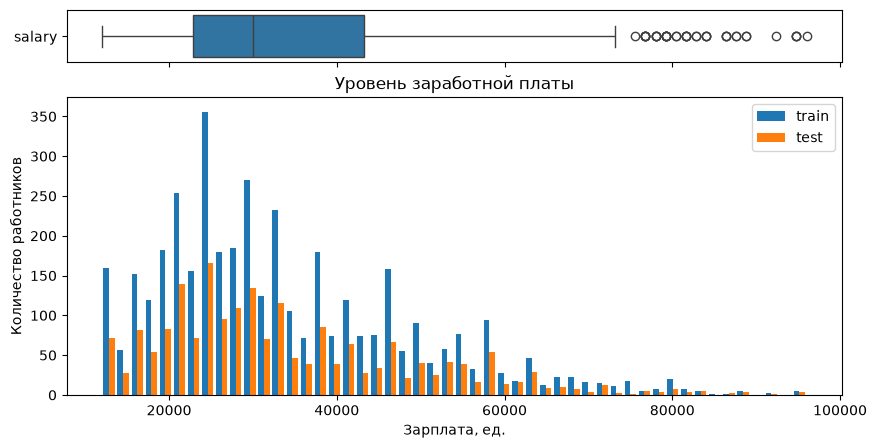

In [37]:
f_hist_box(
    train=train_quit['salary'],
    test=test_quit['salary'],
    bins=50,
    range=(train_quit['salary'].min(), train_quit['salary'].max()),
    title='Уровень заработной платы',
    xlabel='Зарплата, ед.',
    ylabel='Количество работников'
)

### Категориальные данные

In [38]:
train_quit.describe(include='object')

C:\Users\krbsv\AppData\Local\Temp\ipykernel_8800\1529786402.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train_quit.describe(include='object')


,dept,level,workload,last_year_promo,last_year_violations,quit
count,4000,4000,4000,4000,4000,4000
unique,5,3,3,2,2,2
top,sales,junior,medium,no,no,no
freq,1438,1949,2118,3887,3455,2872


In [39]:
test_quit.describe(include='object')

C:\Users\krbsv\AppData\Local\Temp\ipykernel_8800\312554038.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  test_quit.describe(include='object')


,dept,level,workload,last_year_promo,last_year_violations,quit
count,1997,1999,1999,2000,2000,2000
unique,5,3,3,2,2,2
top,sales,junior,medium,no,no,no
freq,763,974,1043,1937,1738,1436


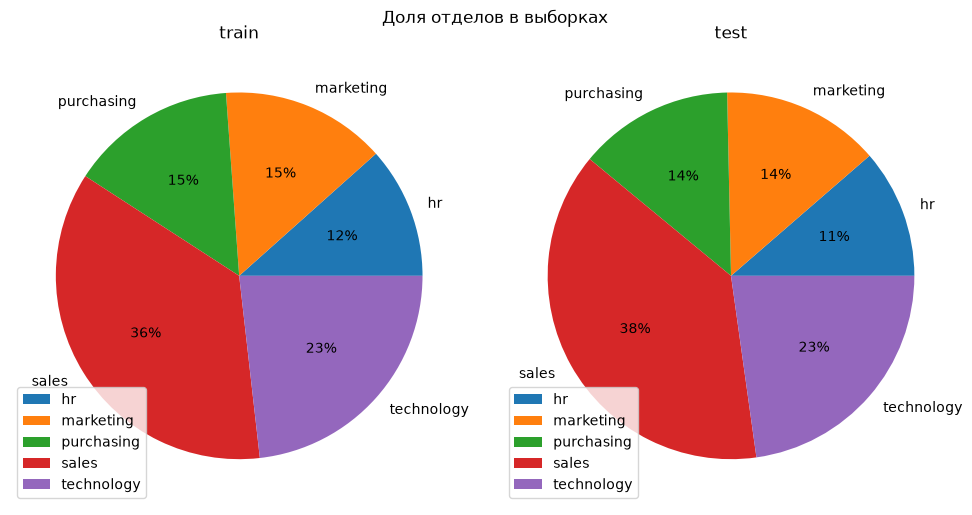

In [40]:
f_pie_x2(train=train_quit, test=test_quit, col='dept', suptitle='Доля отделов в выборках')

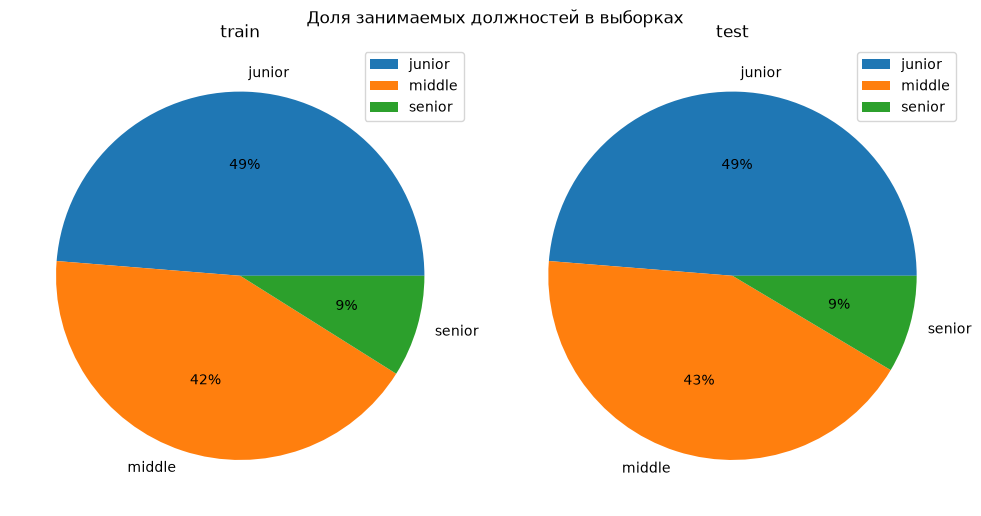

In [41]:
f_pie_x2(train=train_quit, test=test_quit, col='level', suptitle='Доля занимаемых должностей в выборках')

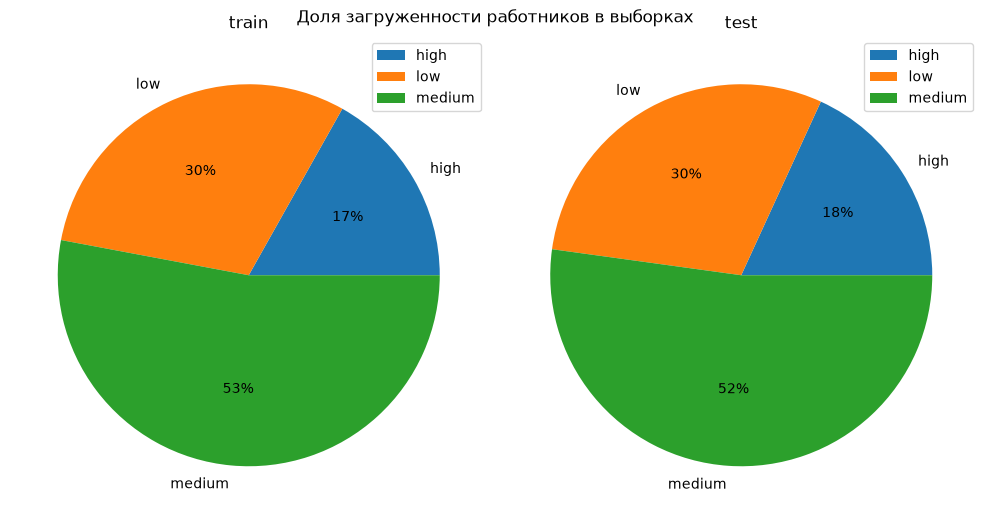

In [42]:
f_pie_x2(train=train_quit, test=test_quit, col='workload', suptitle='Доля загруженности работников в выборках')

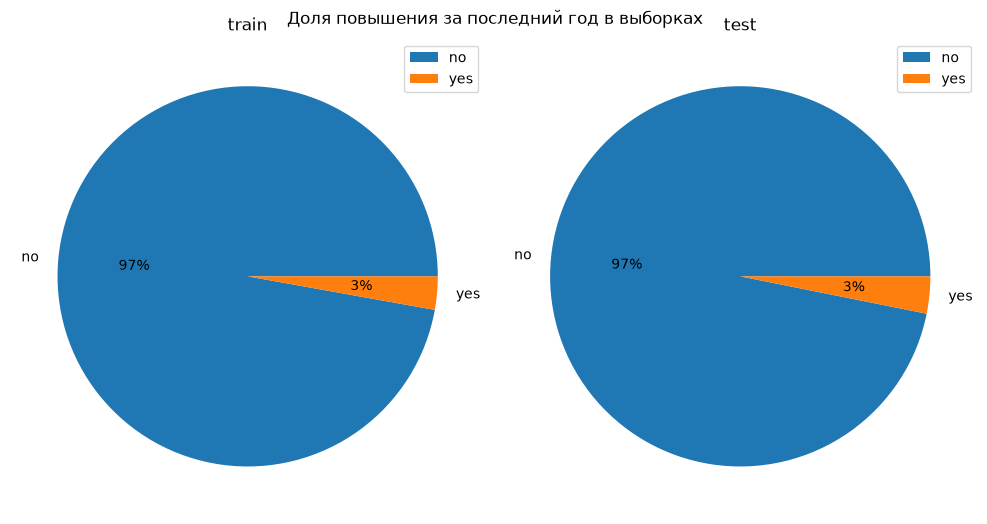

In [43]:
f_pie_x2(train=train_quit, test=test_quit, col='last_year_promo', suptitle='Доля повышения за последний год в выборках')

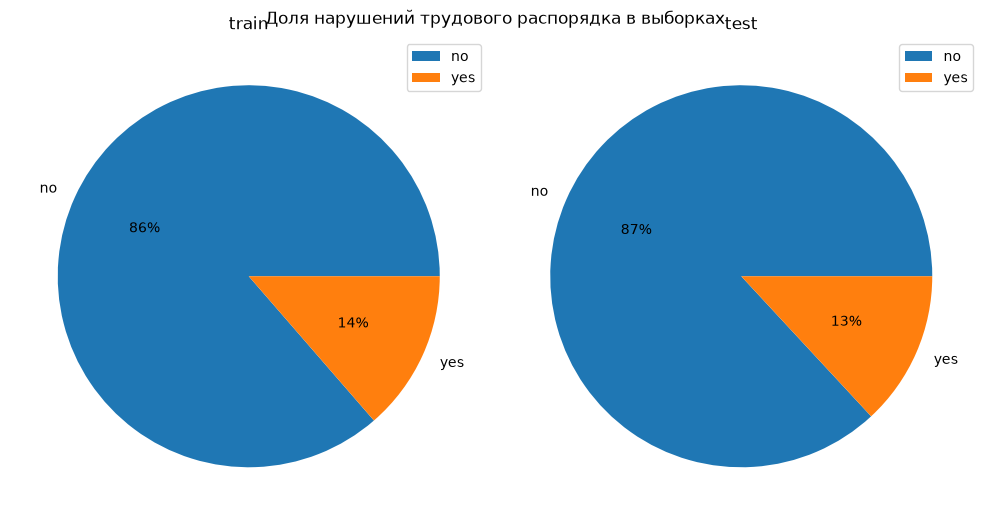

In [44]:
f_pie_x2(train=train_quit, test=test_quit, col='last_year_violations', suptitle='Доля нарушений трудового распорядка в выборках')

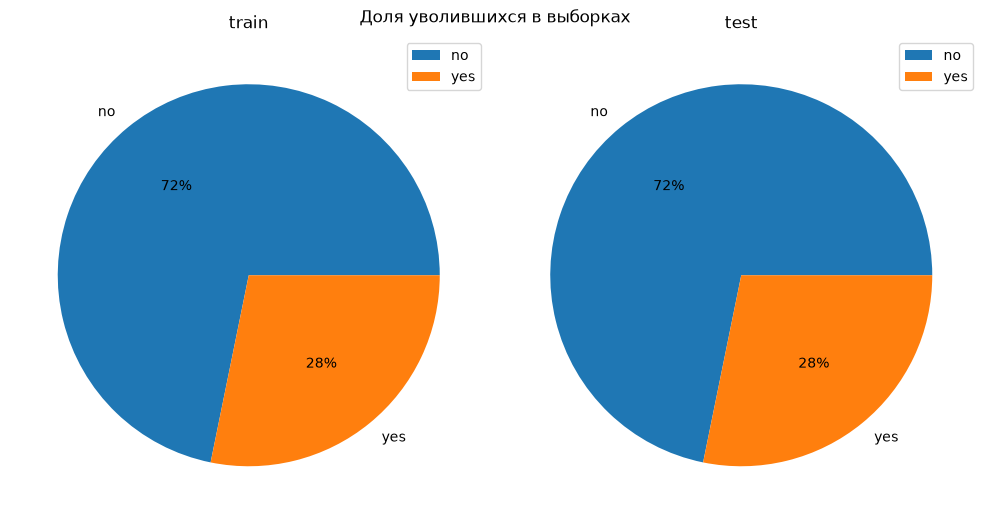

In [45]:
f_pie_x2(train=train_quit, test=test_quit, col='quit', suptitle='Доля уволившихся в выборках')

### Портрет уволившегося сотрудника

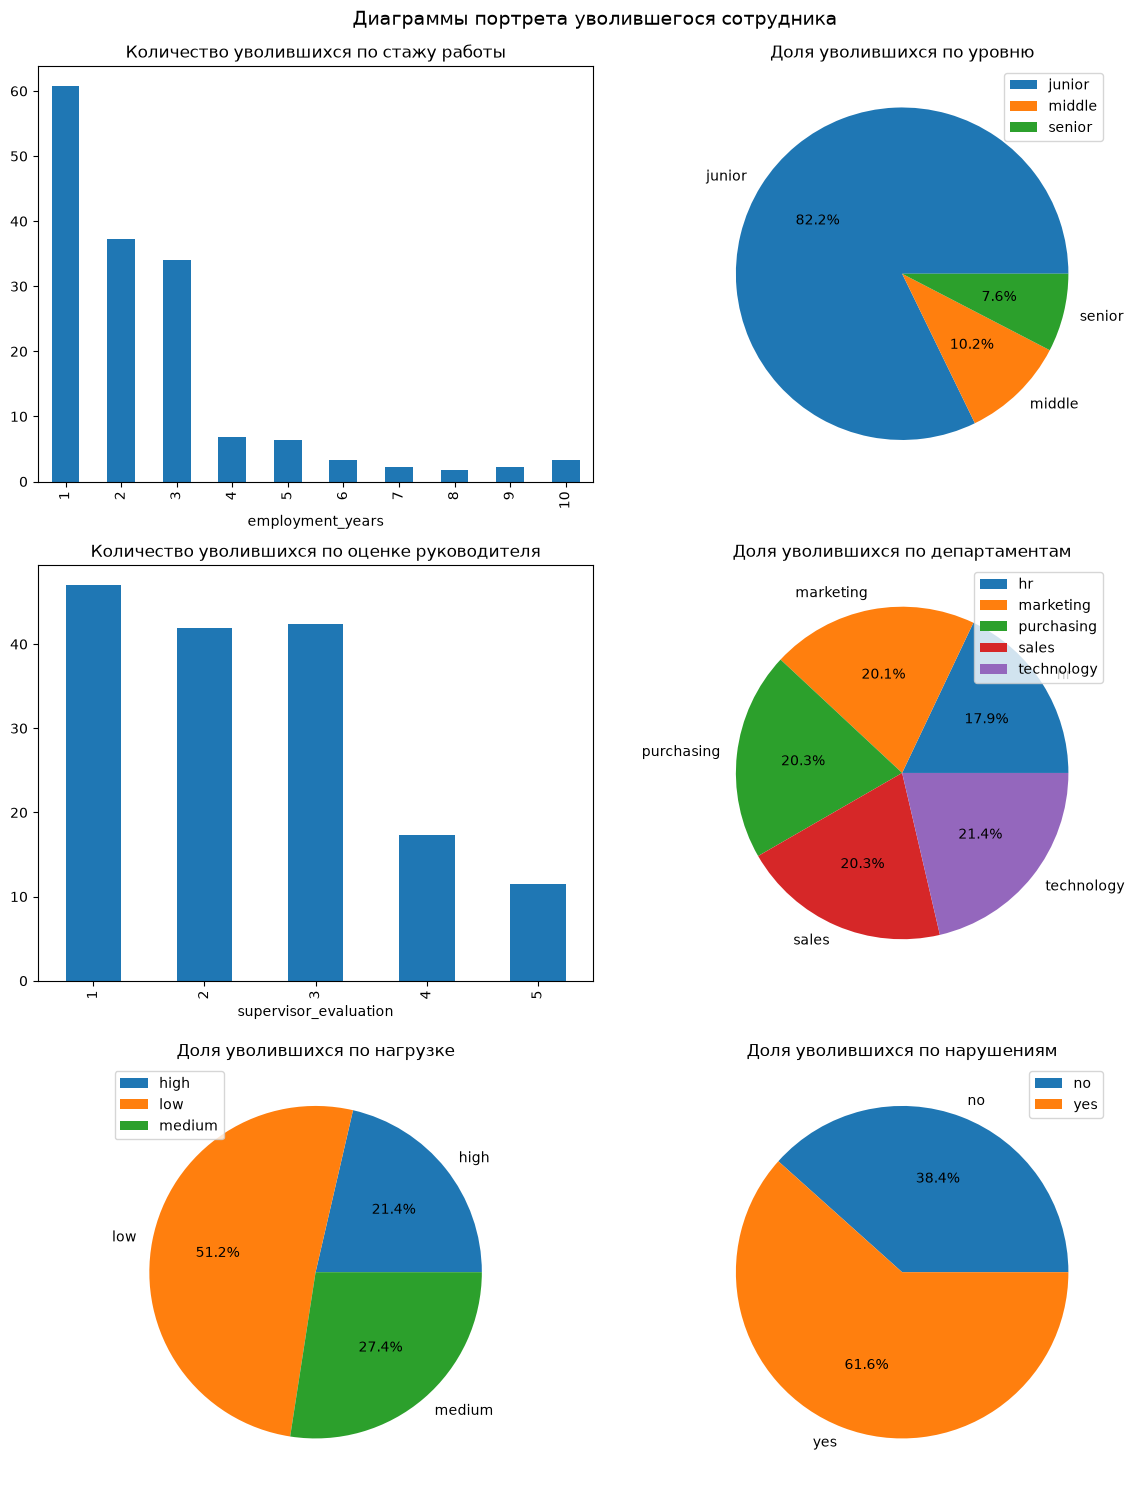

,salary
quit,
no,"34,800.00"
yes,"22,800.00"


In [46]:
def calculate_quit_ratio(data, column):
    return (
        data.groupby(column)['quit']
        .value_counts(normalize=True)
        .mul(100)
        .rename('Доля (%)')
        .reset_index()
        .query('quit == "yes"')
    )

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 15))
fig.suptitle('Диаграммы портрета уволившегося сотрудника', fontsize=14, y=0.99)

quit_ratio_emp_years = calculate_quit_ratio(train_quit, 'employment_years')
quit_ratio_emp_years.plot.bar(x='employment_years', y='Доля (%)', ax=axes[0, 0], legend=False)
axes[0, 0].set_title('Количество уволившихся по стажу работы')

quit_ratio_level = calculate_quit_ratio(train_quit, 'level')
quit_ratio_level.plot.pie(y='Доля (%)', labels=quit_ratio_level['level'], autopct='%1.1f%%', ax=axes[0, 1])
axes[0, 1].set_title('Доля уволившихся по уровню')

quit_ratio_eval = calculate_quit_ratio(train_quit, 'supervisor_evaluation')
quit_ratio_eval.plot.bar(x='supervisor_evaluation', y='Доля (%)', ax=axes[1, 0], legend=False)
axes[1, 0].set_title('Количество уволившихся по оценке руководителя')

quit_ratio_dept = calculate_quit_ratio(train_quit, 'dept')
quit_ratio_dept.plot.pie(y='Доля (%)', labels=quit_ratio_dept['dept'], autopct='%1.1f%%', ax=axes[1, 1])
axes[1, 1].set_title('Доля уволившихся по департаментам')

quit_ratio_workload = calculate_quit_ratio(train_quit, 'workload')
quit_ratio_workload.plot.pie(y='Доля (%)', labels=quit_ratio_workload['workload'], autopct='%1.1f%%', ax=axes[2, 0])
axes[2, 0].set_title('Доля уволившихся по нагрузке')

quit_ratio_violations = calculate_quit_ratio(train_quit, 'last_year_violations')
quit_ratio_violations.plot.pie(y='Доля (%)', labels=quit_ratio_violations['last_year_violations'], autopct='%1.1f%%', ax=axes[2, 1])
axes[2, 1].set_title('Доля уволившихся по нарушениям')

for ax in axes.flatten():
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

train_quit.pivot_table(index='quit', values='salary', aggfunc='median')

### Промежуточный вывод по портрету уволившегося сотрудника

Портрет считан по графикам выше — доли пиковых значений по каждому признаку
среди уволившихся, и медианная зарплата по группам (`quit`) в ячейке выше.
Уволившиеся заметно смещены к небольшому стажу, младшему уровню должности,
невысокой оценке руководителя и зарплате ниже, чем у оставшихся.

### Влияние уровня удовлетворённости сотрудника работой на его увольнение

Объединим данные по `id`.

In [47]:
quit_satisfaction = pd.merge(test_target_quit, test_target_sat, on='id', sort=True).sort_values(by='id')

Построим гистограмму и boxplot.

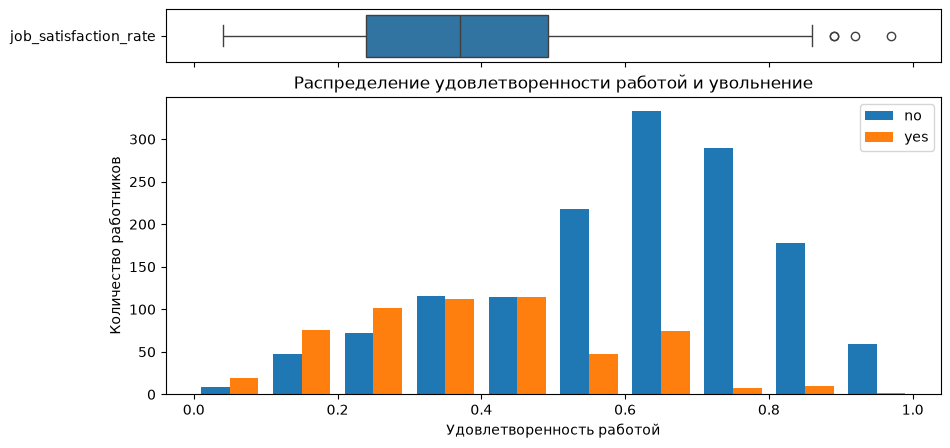

In [48]:
col = 'job_satisfaction_rate'
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, figsize=(10, 5), gridspec_kw={"height_ratios": (.15, .85)})

sns.boxplot(data=[quit_satisfaction[quit_satisfaction['quit'] == 'no'][col],
                  quit_satisfaction[quit_satisfaction['quit'] == 'yes'][col]], orient="h", ax=ax_box)
plt.hist([quit_satisfaction[quit_satisfaction['quit'] == 'no'][col],
          quit_satisfaction[quit_satisfaction['quit'] == 'yes'][col]],
         bins=10, range=(0, 1), label=['no', 'yes'])

plt.legend(loc='upper right')
plt.title('Распределение удовлетворенности работой и увольнение')
plt.xlabel('Удовлетворенность работой')
plt.ylabel('Количество работников')
plt.show()

Построим плотность распределения (KDE) коэффициента удовлетворённости работой.

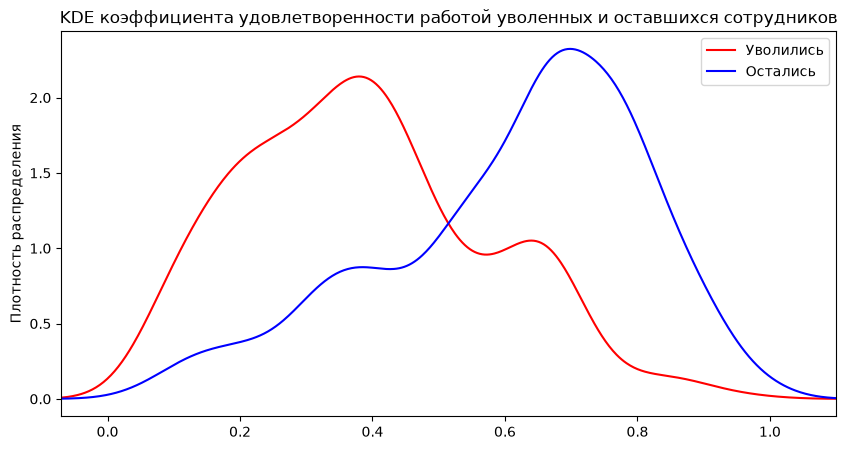

In [49]:
plt.figure(figsize=(10, 5))
plt.title('KDE коэффициента удовлетворенности работой уволенных и оставшихся сотрудников')
plt.xlim(quit_satisfaction['job_satisfaction_rate'].min() - 0.1, quit_satisfaction['job_satisfaction_rate'].max() + 0.1)
ax = quit_satisfaction[quit_satisfaction['quit'] == 'yes']['job_satisfaction_rate'].plot.kde(color='red', label='Уволились')
ax = quit_satisfaction[quit_satisfaction['quit'] == 'no']['job_satisfaction_rate'].plot.kde(color='blue', label='Остались')
ax.set_ylabel('Плотность распределения')
plt.legend()
plt.show()

### Промежуточный вывод
По графикам видна разница: у уволившихся сотрудников удовлетворённость ниже.

Выдвинем гипотезы:
- **H0:** средние значения удовлетворённости в группах равны, зависимости между увольнением и удовлетворённостью нет.
- **H1:** средние значения различаются, зависимость есть.

In [50]:
group1 = quit_satisfaction[quit_satisfaction['quit'] == 'yes']
group2 = quit_satisfaction[quit_satisfaction['quit'] == 'no']

lev = levene(group1['job_satisfaction_rate'], group2['job_satisfaction_rate'])
print(f"Тест Левене: p-value = {lev.pvalue:.2e}")

t_res = ttest_ind(group1['job_satisfaction_rate'], group2['job_satisfaction_rate'], equal_var=(lev.pvalue >= 0.05))
print(f"t-статистика = {t_res.statistic:.2f}, p-value = {t_res.pvalue:.2e}")

Тест Левене: p-value = 2.29e-01
t-статистика = -23.07, p-value = 1.23e-104


p-value меньше 0.05 — отклоняем нулевую гипотезу: зависимость между увольнением и удовлетворённостью статистически значима.

## Добавление предсказанной удовлетворённости как признака

In [51]:
train_quit_idx = train_quit.set_index('id').sort_index()
test_quit_idx = test_quit.set_index('id').sort_index()

train_quit_idx['job_satisfaction_rate'] = best_model_1.predict(train_quit_idx.drop(columns='quit'))
test_quit_idx['job_satisfaction_rate'] = best_model_1.predict(test_quit_idx.drop(columns='quit'))

num_cols_2 = num_cols_1 + ['job_satisfaction_rate']
train_quit_idx[['job_satisfaction_rate']].describe()

,job_satisfaction_rate
count,"4,000.00"
mean,0.54
std,0.22
min,0.03
25%,0.35
50%,0.53
75%,0.68
max,1.00


### Корреляционный анализ

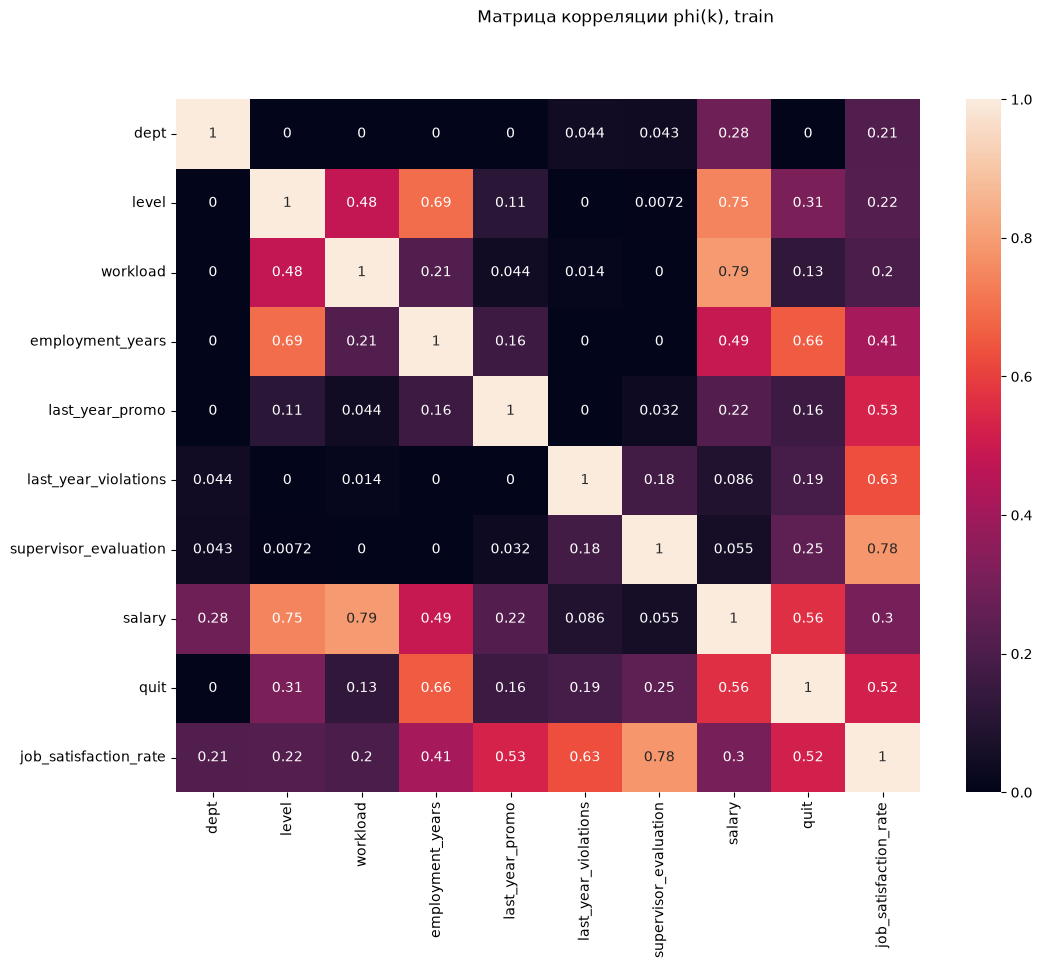

In [52]:
interval_cols_2 = ['salary', 'job_satisfaction_rate']

fig, ax = plt.subplots(figsize=(12, 9))
plt.suptitle('Матрица корреляции phi(k), train')
sns.heatmap(train_quit_idx.phik_matrix(interval_cols=interval_cols_2), annot=True)
plt.show()

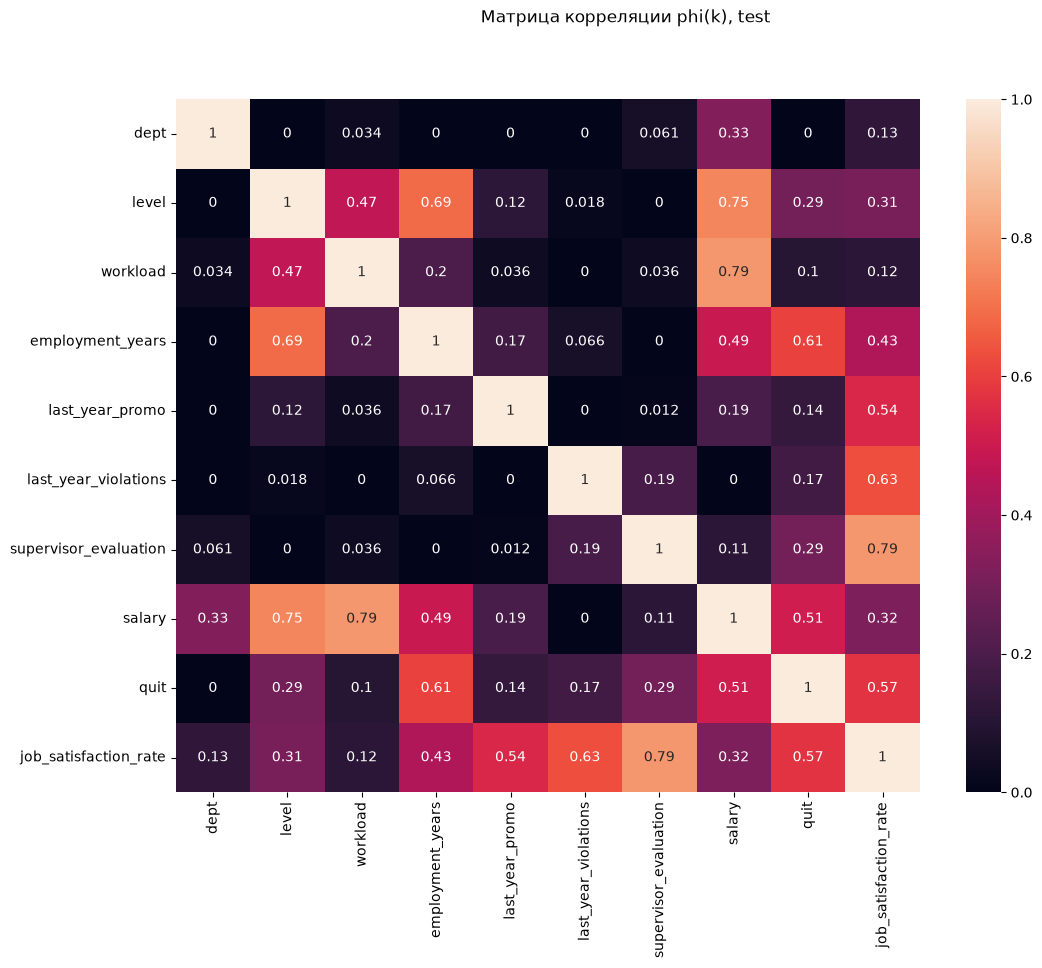

In [53]:
fig, ax = plt.subplots(figsize=(12, 9))
plt.suptitle('Матрица корреляции phi(k), test')
sns.heatmap(test_quit_idx.phik_matrix(interval_cols=interval_cols_2), annot=True)
plt.show()

### Вывод по добавлению признака и корреляциям
+ `id` переведён в индекс, отсортирован по возрастанию.
+ Связи выше 0.9 нет, мультиколлинеарность не проблема.
+ Портрет уволившегося сотрудника: короткий стаж, младший уровень, невысокая оценка руководителя, зарплата ниже медианной.
+ Добавлен признак `job_satisfaction_rate`, полученный моделью задачи 1.
+ Кодирование признаков — то же, что и в задаче 1, плюс `job_satisfaction_rate` в числовые.

## Пайплайн и обучение моделей

In [54]:
preprocessor_2 = ColumnTransformer([
    ('ohe', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
    ]), ohe_cols),
    ('ord', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(categories=[
            ['junior', 'middle', 'senior'],
            ['low', 'medium', 'high'],
        ], handle_unknown='use_encoded_value', unknown_value=np.nan)),
    ]), ord_cols),
    ('num', RobustScaler(), num_cols_2),
])

X_train_2 = train_quit_idx.drop(columns='quit')
y_train_2 = (train_quit_idx['quit'] == 'yes').astype(int)
X_test_2 = test_quit_idx.drop(columns='quit')
y_test_2 = (test_quit_idx['quit'] == 'yes').astype(int)

In [55]:
models_2 = {
    'LogReg': (
        Pipeline([('preprocessor', preprocessor_2), ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'))]),
        {'model__C': [0.1, 1, 3, 10]}
    ),
    'KNeighbors': (
        Pipeline([('preprocessor', preprocessor_2), ('model', KNeighborsClassifier())]),
        {'model__n_neighbors': range(3, 15)}
    ),
    'DecisionTree': (
        Pipeline([('preprocessor', preprocessor_2), ('model', DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'))]),
        {'model__max_depth': [None, 3, 5, 7, 10], 'model__min_samples_leaf': range(1, 10)}
    ),
    'SVC': (
        Pipeline([('preprocessor', preprocessor_2), ('model', SVC(random_state=RANDOM_STATE, probability=True, class_weight='balanced'))]),
        {'model__C': [0.5, 1, 3], 'model__kernel': ['rbf', 'poly']}
    ),
    'HistGradientBoosting': (
        Pipeline([('preprocessor', preprocessor_2), ('model', HistGradientBoostingClassifier(random_state=RANDOM_STATE))]),
        {'model__max_depth': [None, 3, 5, 7], 'model__learning_rate': [0.03, 0.05, 0.1, 0.2]}
    ),
}

results_2 = []
for name, (pipe, params) in models_2.items():
    search = RandomizedSearchCV(pipe, params, n_iter=15, cv=5, scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_train_2, y_train_2)
    results_2.append({'model': name, 'cv_roc_auc': search.best_score_, 'estimator': search.best_estimator_})
    print(f"{name:22s} CV ROC-AUC = {search.best_score_:.4f}")

D:\projects\portfolio\yandex-practicum-projects\hr-satisfaction-attrition\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=15. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
D:\projects\portfolio\yandex-practicum-projects\hr-satisfaction-attrition\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 12 is smaller than n_iter=15. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


LogReg                 CV ROC-AUC = 0.9180


KNeighbors             CV ROC-AUC = 0.9279


DecisionTree           CV ROC-AUC = 0.9333


D:\projects\portfolio\yandex-practicum-projects\hr-satisfaction-attrition\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 6 is smaller than n_iter=15. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


D:\projects\portfolio\yandex-practicum-projects\hr-satisfaction-attrition\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVC                    CV ROC-AUC = 0.9299


HistGradientBoosting   CV ROC-AUC = 0.9406


## Выбор модели и проверка на тесте

In [56]:
results_2_df = pd.DataFrame(results_2).sort_values('cv_roc_auc', ascending=False)
display(results_2_df[['model', 'cv_roc_auc']])

best_2 = results_2_df.iloc[0]
best_model_2_name, best_model_2 = best_2['model'], best_2['estimator']

test_proba_2 = best_model_2.predict_proba(X_test_2)[:, 1]
test_roc_auc = roc_auc_score(y_test_2, test_proba_2)
print(f"\nЛучшая модель: {best_model_2_name}")
print(f"ROC-AUC на тесте: {test_roc_auc:.4f}")

dummy_2 = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE).fit(X_train_2, y_train_2)
dummy_roc_auc = roc_auc_score(y_test_2, dummy_2.predict_proba(X_test_2)[:, 1])
print(f"ROC-AUC DummyClassifier на тесте: {dummy_roc_auc:.4f}")

,model,cv_roc_auc
4,HistGradientBoosting,0.94
2,DecisionTree,0.93
3,SVC,0.93
1,KNeighbors,0.93
0,LogReg,0.92



Лучшая модель: HistGradientBoosting
ROC-AUC на тесте: 0.9317
ROC-AUC DummyClassifier на тесте: 0.4999


## Важность признаков

Встроенная важность дерева/бустинга считается по колонкам после кодирования —
категориальный признак размазывается по нескольким бинарным столбцам. Возьмём
permutation importance по исходным колонкам на всей тестовой выборке.

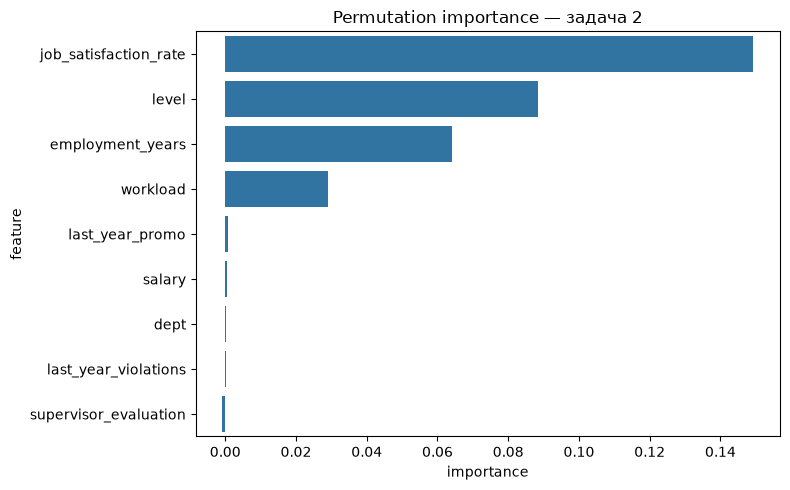

,feature,importance
8,job_satisfaction_rate,0.15
1,level,0.09
3,employment_years,0.06
2,workload,0.03
4,last_year_promo,0.00
7,salary,0.00
0,dept,0.00
5,last_year_violations,0.00
6,supervisor_evaluation,-0.00


In [57]:
perm = permutation_importance(
    best_model_2, X_test_2, y_test_2, scoring='roc_auc',
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

importance_2 = pd.DataFrame({
    'feature': X_test_2.columns,
    'importance': perm.importances_mean,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_2, x='importance', y='feature')
plt.title('Permutation importance — задача 2')
plt.tight_layout()
plt.show()

importance_2

## Общий вывод

**Задача 1.** Лучшая модель существенно превосходит `DummyRegressor`.

**Задача 2.** Перед добавлением предсказанной удовлетворённости как признака
проверено: обучающие выборки задач 1 и 2 не пересекаются по `id`. Лучшая
модель значительно превосходит `DummyClassifier`.
Сильнее всего на решение об увольнении влияют предсказанная удовлетворённость
и стаж — это согласуется с портретом уволившегося сотрудника: короткий стаж,
невысокая оценка руководителя, зарплата ниже медианной.

**Практическая значимость:**
- Модель удовлетворённости снижает зависимость от ручных опросников.
- Модель оттока помогает приоритизировать разговоры с сотрудниками из группы риска, особенно в первый год работы.
- Разрыв в зарплате между уволившимися и оставшимися — потенциально самый дешёвый рычаг удержания, стоит проверить отдельно.

## Что бы сделал иначе

В исходной версии проекта важность признаков для модели оттока считалась
SHAP-методом на одном наблюдении и подавалась как общий вывод — заменил на
permutation importance по всей тестовой выборке. Также добавил явную проверку
пересечения `id` между `train_job_satisfaction_rate` и `train_quit` перед
переносом признака между задачами: конструкция была правильной и без этого,
но теперь это доказано, а не предполагалось.